---
title: "CNN Multi-class classification Keras"
author: "Jorge Bris Moreno"
format:
  html:
    embed-resources: true
---

## Lab-3.1: CNN Multi-class classification 

In this lab we perform multi-class classification with a CNN using `PyTorch` **AND** `Keras`. 

**Submission:**

* You need to upload TWO documents to Canvas when you are done
  * (1) A PDF (or HTML) of the completed form of the completed `MNIST.ipynb` notebook (MNIST in Keras)
  * (1) A PDF (or HTML) of the completed form of the completed `CIFAR.ipynb` notebook (CIFAR in PyTorch)
* The final uploaded version should NOT have any code-errors present 
* All outputs must be visible in the uploaded version, including code-cell outputs, images, graphs, etc

**Instructions** 

* Code Multi-class classification using LeNet type architecture CNN to train
  * (1) MNIST training with Keras, in `MNIST.ipynb`.
  * (2) CIFAR training with PyTorch, in `CIFAR.ipynb`.
  * **If you use an online reference, please cite the source and don't copy more than a few lines of code**
  * Normalize the data as needed
  * Visualize the results at the end where possible
  * Partition data into training, validation, and test
  * Monitor training and validation throughout training by plotting
  * For the final fit, report the confusion matrix at the end
  * Print training, validation, and test errors at the very end
  * You `MUST` use early stopping: 
  * Do basic `MANUAL` hyper-parameter tuning to try to achieve an optimal fit model
    * i.e. best training/validation loss without over-fitting
    * Explore L1 and L2 regularization and dropout
    * Explore different optimizers 
    * Use the loss functions specified in the textbook
    * Explore different options for activation functions, network size/depth, etc
* **Document what is going on in the code, as needed, with narrative markdown text between cells.**
* *Submit the version with hyper parameters that provide the optimal fit*
  * i.e. you don't need to show the outputs of your hyper-parameter tuning process

## Architecture:
I will be using LeNet 5 architecture for this task, as we know it works specially well for MNIST dataset. Furthermore, the hyperparameters have been tuned as described and my optimal ones are the ones in this version.


In [1]:
# libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd
from keras import regularizers

2024-03-12 10:01:00.637993: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Here we load the data and reshape it to the correct format. We also normalize it.

In [2]:
# Load dataset
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

# Normalize data
train_data = train_data.astype('float32') / 255.0
test_data = test_data.astype('float32') / 255.0

# Reshape the data to add dimension chanel
train_data = train_data.reshape((-1, 28, 28, 1))
test_data = test_data.reshape((-1, 28, 28, 1))

print("Train data shape before padding:", train_data.shape)
print("Test data shape before padding:", test_data.shape)

Train data shape before padding: (60000, 28, 28, 1)
Test data shape before padding: (10000, 28, 28, 1)


In [3]:
# making labels to categorical
train_y = to_categorical(train_labels, num_classes = 10)
test_y = to_categorical(test_labels, num_classes = 10)

We split training data into training and validation data for training purposes.

In [4]:
# creating validation data
train_data, val_data, train_y, val_y = train_test_split(train_data, train_y, test_size=0.2, random_state=42)

This code creates the model with the architecture set in the example in the website of LeNet 5. The hyperparameters have been tuned to the optimal ones.


In [5]:
# Model
model = Sequential()
model.add(Conv2D(filters=6, kernel_size=(5,5), padding='same', activation='relu', input_shape=(28, 28, 1), kernel_regularizer=regularizers.l2(0.0), bias_regularizer=regularizers.l1(0.01)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(filters=16, kernel_size=(5,5), padding='valid', activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(84, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [6]:
model.build()
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 6)         156       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 6)         0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 10, 10, 16)        2416      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 400)               0         
                                                                 
 dense (Dense)               (None, 256)               1

We now compile the model with the Adam optimizer and the categorical crossentropy loss function. We also set the metrics to accuracy.

In [7]:
model.compile(optimizer=Adam(learning_rate=1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

We have found in keras and tensorflow documentation that there is a way to reduce the learning rate when the validation loss stops improving. This is done with the ReduceLROnPlateau callback. We will use this callback to reduce the learning rate by a factor of 0.2 if the validation loss does not improve in 3 epochs.

In [8]:
# learning rate annealer
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', 
                              patience=3, 
                              verbose=1, 
                              factor=0.2, 
                              min_lr=1e-6)

early_stopping = EarlyStopping(monitor='val_accuracy', patience=4, verbose=1)

We fit the model, train it, and test it.

In [9]:
history = model.fit(train_data, train_y, epochs=50, batch_size=64, validation_data=(val_data, val_y), callbacks=[reduce_lr, early_stopping])

Epoch 1/50
750/750 [==============================] - 14s 17ms/step - loss: 0.7968 - accuracy: 0.7721 - val_loss: 0.2479 - val_accuracy: 0.9270 - lr: 1.0000e-04
Epoch 2/50
750/750 [==============================] - 13s 18ms/step - loss: 0.2313 - accuracy: 0.9294 - val_loss: 0.1574 - val_accuracy: 0.9542 - lr: 1.0000e-04
Epoch 3/50
750/750 [==============================] - 13s 18ms/step - loss: 0.1645 - accuracy: 0.9502 - val_loss: 0.1158 - val_accuracy: 0.9669 - lr: 1.0000e-04
Epoch 4/50
750/750 [==============================] - 13s 18ms/step - loss: 0.1295 - accuracy: 0.9612 - val_loss: 0.0942 - val_accuracy: 0.9726 - lr: 1.0000e-04
Epoch 5/50
750/750 [==============================] - 15s 20ms/step - loss: 0.1071 - accuracy: 0.9669 - val_loss: 0.0847 - val_accuracy: 0.9749 - lr: 1.0000e-04
Epoch 6/50
750/750 [==============================] - 14s 19ms/step - loss: 0.0939 - accuracy: 0.9713 - val_loss: 0.0728 - val_accuracy: 0.9784 - lr: 1.0000e-04
Epoch 7/50
750/750 [==============

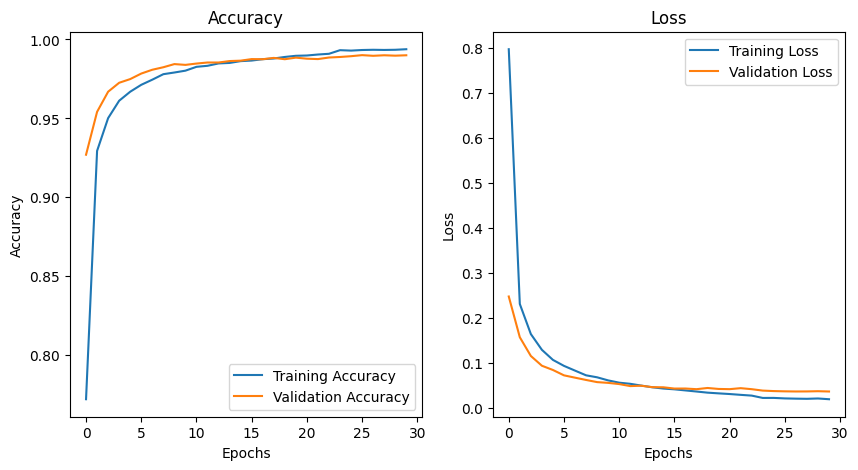

In [10]:
# Plot training and validation accuracy/loss
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [11]:
test_loss, test_accuracy = model.evaluate(test_data, test_y)
print("Test accuracy:", test_accuracy)

313/313 [==============================] - 1s 3ms/step - loss: 0.0276 - accuracy: 0.9912
Test accuracy: 0.9911999702453613


313/313 [==============================] - 1s 3ms/step
Predictions shape: (10000, 10)
Test labels shape (one-hot): (10000, 10)


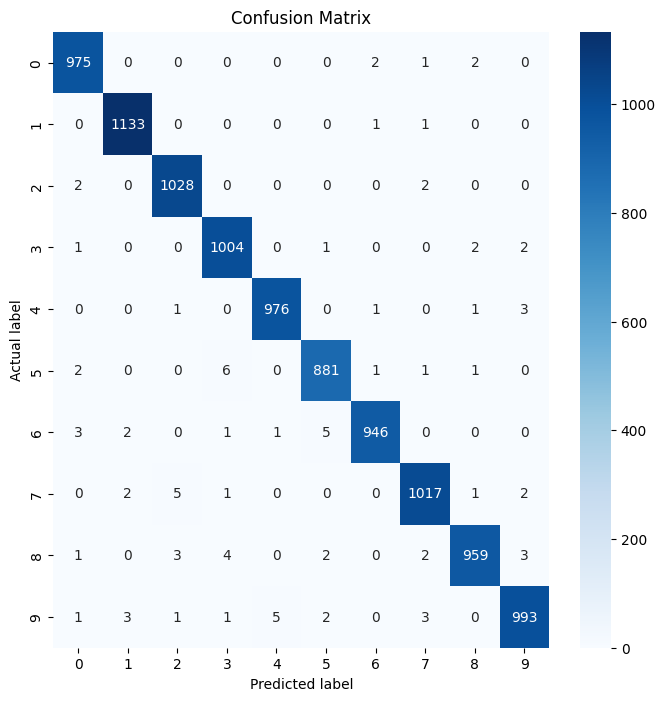

In [12]:
# model.predict
predictions = model.predict(test_data)
print("Predictions shape:", predictions.shape)

# for debugging
print("Test labels shape (one-hot):", test_y.shape)

# Confusion Matrix
cm = confusion_matrix(np.argmax(test_y, axis=1), np.argmax(predictions, axis=1))

plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title('Confusion Matrix')
plt.ylabel('Actual label')
plt.xlabel('Predicted label')
plt.show()